# Graphicalizing Aesop's Fables

This notebook downloads the public-domain Project Gutenberg text for [Æsop's Fables #53103](https://www.gutenberg.org/ebooks/53103), splits it into tale-sized documents, and sends those documents through the ontology-guided semantic pipeline.

The notebook uses the package's default OpenAI `gpt-4.1-mini` client. Set `OPENAI_API_KEY` in the environment before running the model cell. The key is read by the OpenAI SDK and is never stored in this notebook.

In [1]:
%config InlineBackend.figure_format = 'retina'

%load_ext autoreload
%autoreload 2

from pathlib import Path
from IPython.display import display

from semantic_graphicalizer import SemanticGraphicalizer, load_aesop_fables

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent

stories = load_aesop_fables(limit=1, cache_dir=ROOT / 'data' / 'raw', select_at_random=True, rand_seed=None)
[(story.splitlines()[0], len(story)) for story in stories]

[('The Mule', 416)]

## OpenAI model

The transformer creates the default `OpenAIModelClient` when `model` is omitted. It uses `gpt-4.1-mini` through the Responses API and reads `OPENAI_API_KEY` from the environment.

In [2]:
from textwrap import wrap

graphicalizer = SemanticGraphicalizer(
    ontology=ROOT / 'configs' / 'ontologies' / 'aesop.yaml',
    prompts=ROOT / 'configs' / 'prompts' / 'aesop.yaml',
)

graphs = graphicalizer.transform(stories)

for index, (story, graph) in enumerate(zip(stories, graphs), start=1):
    title = story.splitlines()[0]
    relation_nodes = [
        (node_id, data)
        for node_id, data in graph.nodes(data=True)
        if data.get("relation") is not None
    ]
    print(f"\nDocument {index}/{len(stories)}: {title}")
    print("\n".join(wrap(story, width=80)))
    print(f"ID: {graph.graph['document_id']}")
    print(f"Relations: {len(relation_nodes)} | Nodes: {graph.number_of_nodes()} | Edges: {graph.number_of_edges()}")
    print("-" * 80)
    for relation_id, data in relation_nodes:
        arguments = ", ".join(
            f"{edge.get('role')}={target}"
            for _source, target, edge in graph.out_edges(relation_id, data=True)
        )
        print(f"- {data['type']}[{data['relation']}]({arguments})")
    print("\nGraph:")
    display(graphicalizer.display(graph, mode="text"))
    print("=" * 80)


[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-b4937ebb2976] segment: 1 -> 1 | 0.1 ms | input_chars=416, chunk_chars=416
[document-b4937ebb2976 chunk-0] summarize: 1 -> 1 | 4212.4 ms
[document-b4937ebb2976 chunk-0] normalize: 1 -> 1 | 1759.8 ms
[document-b4937ebb2976 chunk-0] decompose: 1 -> 10 | 4726.7 ms
[document-b4937ebb2976 chunk-0] extract: 10 -> 20 | 13434.1 ms
[document-b4937ebb2976] resolve: 20 -> 0 | 1404.2 ms
[document-b4937ebb2976] integrate: 9 -> 18 | 1.1 ms | nodes=20, edges=18
[document-b4937ebb2976] total: 1 -> 1 | 25539.1 ms | chunks=1, entities=11, relations=9, nodes=20, edges=18

Document 1/1: The Mule
The Mule   A MULE, frolicsome from lack of work and from too much corn, galloped
about in a very extravagant manner, and said to himself: “My father surely was a
high-mettled racer, and I am his own child in speed and spirit.” On the next
day, being driven a long journey, and feeling very wearied, he e

character: The Mule
    has_trait: trait: frolicsome
    has_trait: trait: extravagant
    performs: action: galloping about
    wants: goal: to prove his speed and spirit
    has_trait: trait: belief that his father was a high-mettled racer
    teaches: moral: youthful pride can be mistaken
    teaches: moral: challenges reveal true nature
action: being driven on a long journey and becoming wearied
    [temporal] before: action: reevaluates his perception
action: concludes that his father could have been only an ass
    [temporal] after: action: reevaluates his perception

In [3]:
graphicalizer.display(
    graphs[0],
    mode="dynamic",
    layout="force",
    show_derived_links=True,
    show_source=True,
    max_width=34,
    width=1200,
    height=760,
    charge_strength=-10,
    link_distance=150,
    component_spacing=100,
    component_strength=0.3,
    parallel_edge_spacing=320
)

## Convert to AbstractGraph and visualize

The AbstractGraph display shows the reified base graph and its interpretation graph, including their mapping. Each reified base node maps to its own interpretation node, labeled by entity type; document and chunk identifiers remain in metadata. The layout uses undirected Kamada–Kawai distances by default while drawing the original directed edges.

<Axes: >

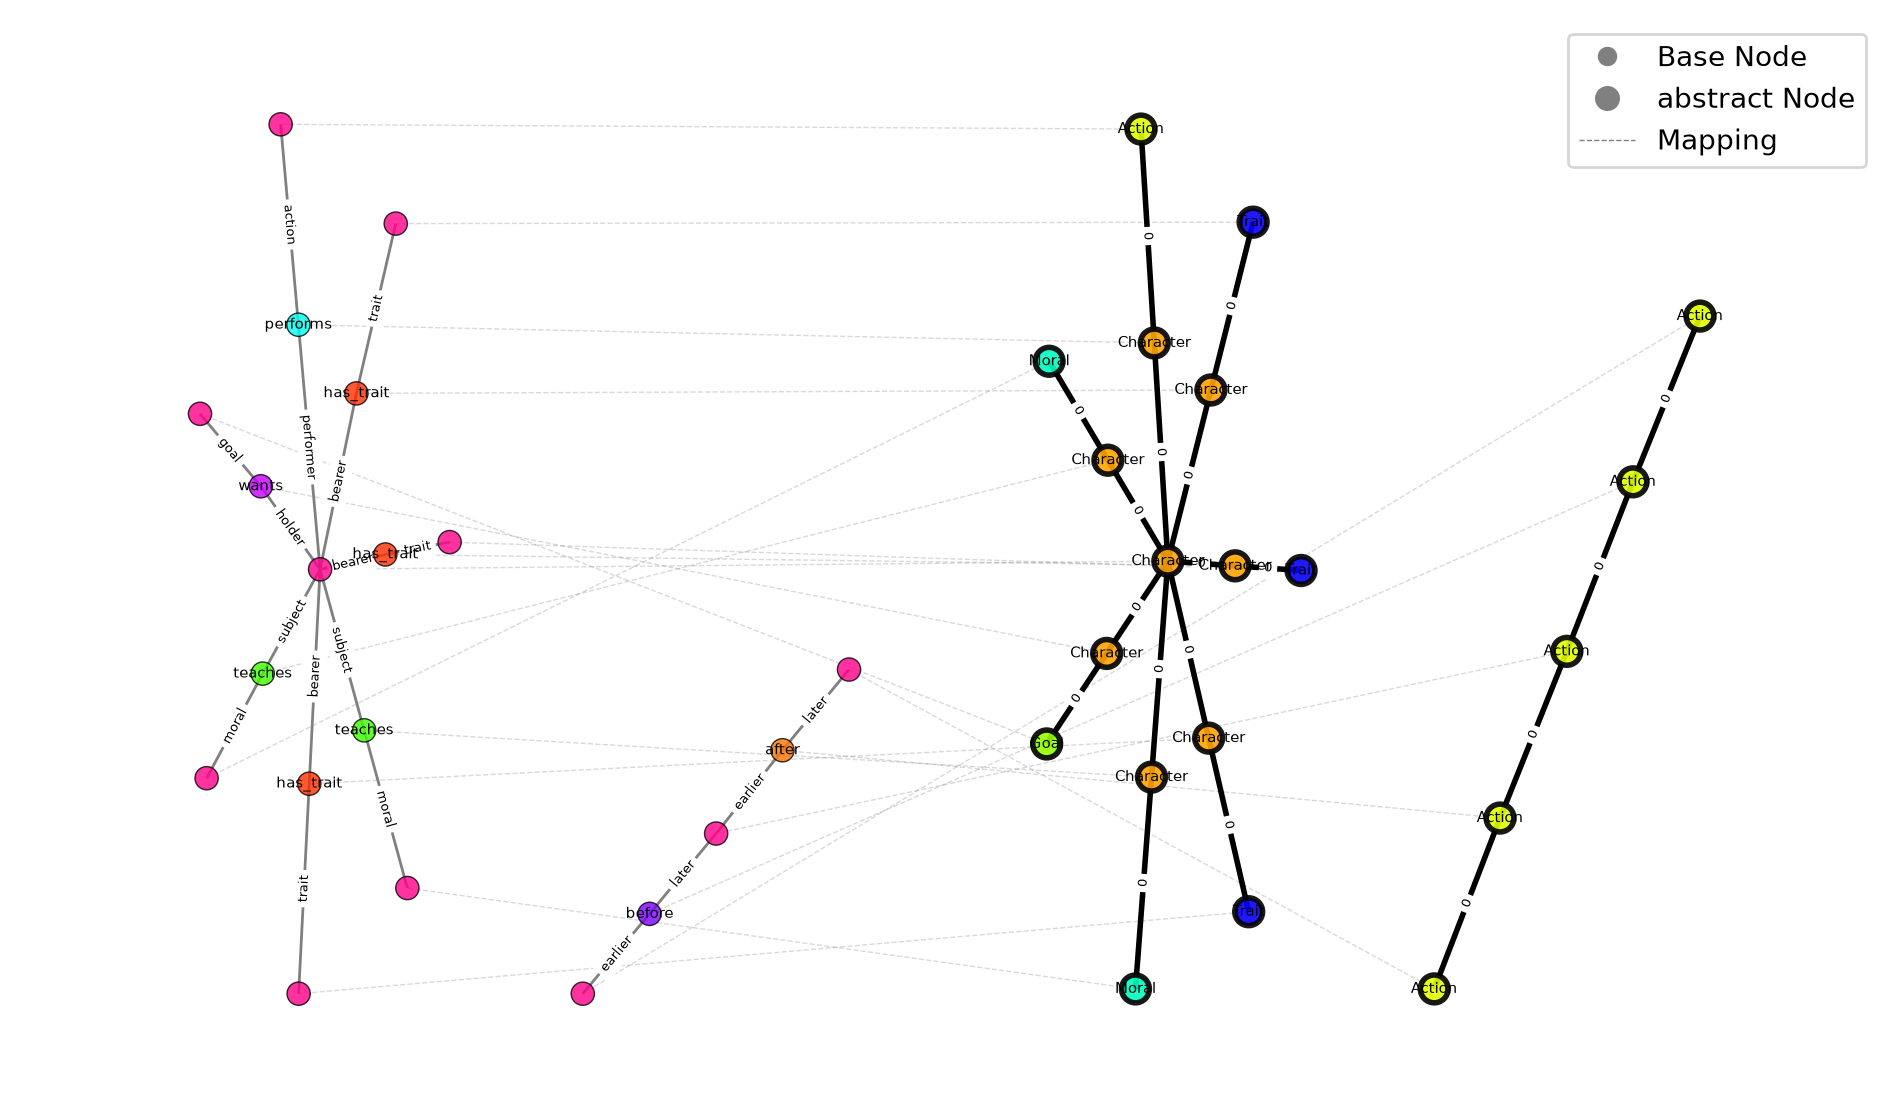

In [4]:
from abstractgraph import display as display_abstract_graph

abstract_graph = graphicalizer.to_abstract_graph(
    graphs[0],
    interpretation_mode="per_entity",
    preserve_direction=False,
    embed_nodes=True,
    embedding_dim=64,
    parallel_edge_policy="first",
)

from abstractgraph.operators import *
abstract_graph = intersection_edges(abstract_graph, accept_connection_by_edge=True)
display_abstract_graph(
    abstract_graph,
    size=(12, 7),
    show_legend=True,
    node_labels=True,
    node_label_attr="label",
    node_label_font_size=5.5,
    edge_labels=True,
    edge_label_font_size=4.5,
    undirected_layout=True,
)